In [1]:
# ============================================
# Cell 1: Imports and directory setup
# ============================================

from pathlib import Path

import numpy as np
import pandas as pd

# Base project directory (where this notebook lives)
PROJECT_DIR = Path.cwd()

# Data directories
RAW_DIR = PROJECT_DIR / "raw"
PROCESSED_DIR = PROJECT_DIR / "processed"
BLS_DIR = RAW_DIR / "bls_food_at_home"

print("Project directory:", PROJECT_DIR)
print("Raw data directory:", RAW_DIR)
print("Processed data directory:", PROCESSED_DIR)
print("BLS food-at-home directory:", BLS_DIR)

# Quick existence check
print("\nDirectory existence check:")
print("RAW_DIR exists:", RAW_DIR.exists())
print("PROCESSED_DIR exists:", PROCESSED_DIR.exists())
print("BLS_DIR exists:", BLS_DIR.exists())


Project directory: /Users/arnavjain/DS_6021_Final_Project
Raw data directory: /Users/arnavjain/DS_6021_Final_Project/raw
Processed data directory: /Users/arnavjain/DS_6021_Final_Project/processed
BLS food-at-home directory: /Users/arnavjain/DS_6021_Final_Project/raw/bls_food_at_home

Directory existence check:
RAW_DIR exists: True
PROCESSED_DIR exists: True
BLS_DIR exists: True


In [2]:
# ============================================
# Cell 2 (final): Load raw CSV data robustly
# ============================================

from pandas.errors import ParserError

data_paths = {
    "acs_race": RAW_DIR / "ACSDT1Y2024.B02001-Data.csv",      # race breakdown
    "acs_income": RAW_DIR / "ACSDT1Y2024.B19013-Data.csv",    # median household income (if needed)
    "acs_poverty": RAW_DIR / "ACSST1Y2024.S1701-Data.csv",    # poverty status
    "rppi": RAW_DIR / "rpi_rpce_rpps.csv",                    # regional price parities / cost of living
    "rural_urban": RAW_DIR / "Ruralurbancontinuumcodes2023.csv",
    "snap_benefits": RAW_DIR / "snap-benefits-8.csv",
    "snap_persons": RAW_DIR / "snap-persons-8.csv",
    "state_trifecta": RAW_DIR / "state_trifecta_2024.csv",
    "snap_regions": RAW_DIR / "usda_snap_regions.csv",
}

dfs = {}

for name, path in data_paths.items():
    try:
        # Try standard CSV with forgiving decoding
        df = pd.read_csv(path, dtype=str, encoding_errors="replace")
        sep_used = ","
    except ParserError:
        # Fallback: try tab-separated (still forgiving decoding)
        try:
            df = pd.read_csv(path, dtype=str, sep="\t", encoding_errors="replace")
            sep_used = "\\t (tab)"
        except Exception as e:
            print(f"!! {name:15s} FAILED to load from {path.name}: {e}")
            continue
    except FileNotFoundError:
        print(f"!! {name:15s} NOT FOUND at {path}")
        continue

    dfs[name] = df
    print(f"{name:15s} loaded from {path.name:35s} sep={sep_used} -> shape {df.shape}")

# Unpack into named variables for convenience
acs_race       = dfs.get("acs_race")
acs_income     = dfs.get("acs_income")
acs_poverty    = dfs.get("acs_poverty")
rppi           = dfs.get("rppi")
rural_urban    = dfs.get("rural_urban")
snap_benefits  = dfs.get("snap_benefits")
snap_persons   = dfs.get("snap_persons")
state_trifecta = dfs.get("state_trifecta")
snap_regions   = dfs.get("snap_regions")


acs_race        loaded from ACSDT1Y2024.B02001-Data.csv         sep=, -> shape (53, 23)
acs_income      loaded from ACSDT1Y2024.B19013-Data.csv         sep=, -> shape (53, 5)
acs_poverty     loaded from ACSST1Y2024.S1701-Data.csv          sep=, -> shape (53, 375)
!! rppi            NOT FOUND at /Users/arnavjain/DS_6021_Final_Project/raw/rpi_rpce_rpps.csv
rural_urban     loaded from Ruralurbancontinuumcodes2023.csv    sep=, -> shape (9703, 5)
snap_benefits   loaded from snap-benefits-8.csv                 sep=, -> shape (66, 6)
snap_persons    loaded from snap-persons-8.csv                  sep=, -> shape (67, 6)
state_trifecta  loaded from state_trifecta_2024.csv             sep=, -> shape (50, 2)
snap_regions    loaded from usda_snap_regions.csv               sep=, -> shape (55, 2)


In [3]:
# ============================================
# Cell 3: Inspect schemas and sample rows
# ============================================

def show_info(name, df, n_cols=8, n_rows=5):
    if df is None:
        print(f"\n{name}: DataFrame is None")
        return
    print("\n" + "="*80)
    print(f"{name} — shape: {df.shape}")
    print("- Columns:")
    print(list(df.columns))
    print("- Sample:")
    # Show only the first few columns so it isn't overwhelming
    display(df.iloc[:n_rows, :n_cols])

# Inspect each key dataset
show_info("acs_race", acs_race)
show_info("acs_income", acs_income)
show_info("acs_poverty", acs_poverty)
show_info("rppi (cost of living)", rppi)
show_info("rural_urban", rural_urban)
show_info("snap_benefits", snap_benefits)
show_info("snap_persons", snap_persons)
show_info("state_trifecta", state_trifecta)
show_info("snap_regions", snap_regions)



acs_race — shape: (53, 23)
- Columns:
['GEO_ID', 'NAME', 'B02001_001E', 'B02001_001M', 'B02001_002E', 'B02001_002M', 'B02001_003E', 'B02001_003M', 'B02001_004E', 'B02001_004M', 'B02001_005E', 'B02001_005M', 'B02001_006E', 'B02001_006M', 'B02001_007E', 'B02001_007M', 'B02001_008E', 'B02001_008M', 'B02001_009E', 'B02001_009M', 'B02001_010E', 'B02001_010M', 'Unnamed: 22']
- Sample:


,GEO_ID,NAME,B02001_001E,B02001_001M,B02001_002E,B02001_002M,B02001_003E,B02001_003M
0,Geography,Geographic Area Name,Estimate!!Total:,Margin of Error!!Total:,Estimate!!Total:!!White alone,Margin of Error!!Total:!!White alone,Estimate!!Total:!!Black or African American alone,Margin of Error!!Total:!!Black or African Amer...
1,0400000US01,Alabama,5157699,*****,3301529,10356,1302107,9734
2,0400000US02,Alaska,740133,*****,434520,3307,18548,3228
3,0400000US04,Arizona,7582384,*****,4345673,23871,360868,13306
4,0400000US05,Arkansas,3088354,*****,2105944,10689,437805,7124



acs_income — shape: (53, 5)
- Columns:
['GEO_ID', 'NAME', 'B19013_001E', 'B19013_001M', 'Unnamed: 4']
- Sample:


,GEO_ID,NAME,B19013_001E,B19013_001M,Unnamed: 4
0,Geography,Geographic Area Name,Estimate!!Median household income in the past ...,Margin of Error!!Median household income in th...,NaN
1,0400000US01,Alabama,66659,780,NaN
2,0400000US02,Alaska,95665,3278,NaN
3,0400000US04,Arizona,81486,684,NaN
4,0400000US05,Arkansas,62106,831,NaN



acs_poverty — shape: (53, 375)
- Columns:
['GEO_ID', 'NAME', 'S1701_C01_001E', 'S1701_C01_001M', 'S1701_C01_002E', 'S1701_C01_002M', 'S1701_C01_003E', 'S1701_C01_003M', 'S1701_C01_004E', 'S1701_C01_004M', 'S1701_C01_005E', 'S1701_C01_005M', 'S1701_C01_006E', 'S1701_C01_006M', 'S1701_C01_007E', 'S1701_C01_007M', 'S1701_C01_008E', 'S1701_C01_008M', 'S1701_C01_009E', 'S1701_C01_009M', 'S1701_C01_010E', 'S1701_C01_010M', 'S1701_C01_011E', 'S1701_C01_011M', 'S1701_C01_012E', 'S1701_C01_012M', 'S1701_C01_013E', 'S1701_C01_013M', 'S1701_C01_014E', 'S1701_C01_014M', 'S1701_C01_015E', 'S1701_C01_015M', 'S1701_C01_016E', 'S1701_C01_016M', 'S1701_C01_017E', 'S1701_C01_017M', 'S1701_C01_018E', 'S1701_C01_018M', 'S1701_C01_019E', 'S1701_C01_019M', 'S1701_C01_020E', 'S1701_C01_020M', 'S1701_C01_021E', 'S1701_C01_021M', 'S1701_C01_022E', 'S1701_C01_022M', 'S1701_C01_023E', 'S1701_C01_023M', 'S1701_C01_024E', 'S1701_C01_024M', 'S1701_C01_025E', 'S1701_C01_025M', 'S1701_C01_026E', 'S1701_C01_026M', 'S

...

,SUPPLEMENTAL NUTRITION ASSISTANCE PROGRAM: NUMBER OF PERSONS PARTICIPATING,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,"(Data as of August 8, 2025)",NaN,NaN,NaN,NaN,NaN
1,State / Territory,May 2024\n,April 2025\nPreliminary,May 2025\nInitial,Percent Change\nMay 2025 vs\nApril 2025,Percent Change\nMay 2025 vs\nMay 2024
2,Alabama,"749,707","737,704","736,178",-0.2%,-1.8%
3,Alaska,"79,542","63,507","66,377",4.5%,-16.6%
4,American Samoa,--,--,--,--,--



state_trifecta — shape: (50, 2)
- Columns:
['state', 'trifecta_2024']
- Sample:


,state,trifecta_2024
0,Alabama,Republican
1,Alaska,Republican
2,Arizona,Divided
3,Arkansas,Republican
4,California,Democratic



snap_regions — shape: (55, 2)
- Columns:
['state', 'usda_snap_region']
- Sample:


,state,usda_snap_region
0,Delaware,Mid-Atlantic
1,District of Columbia,Mid-Atlantic
2,Maryland,Mid-Atlantic
3,New Jersey,Mid-Atlantic
4,Pennsylvania,Mid-Atlantic


In [4]:
# -------------------------------
# Build state lookup reference
# -------------------------------

# Source: Census Bureau standard state list
state_ref = pd.DataFrame({
    "state_name": [
        "Alabama","Alaska","Arizona","Arkansas","California","Colorado","Connecticut","Delaware",
        "District of Columbia","Florida","Georgia","Hawaii","Idaho","Illinois","Indiana","Iowa",
        "Kansas","Kentucky","Louisiana","Maine","Maryland","Massachusetts","Michigan","Minnesota",
        "Mississippi","Missouri","Montana","Nebraska","Nevada","New Hampshire","New Jersey",
        "New Mexico","New York","North Carolina","North Dakota","Ohio","Oklahoma","Oregon",
        "Pennsylvania","Rhode Island","South Carolina","South Dakota","Tennessee","Texas","Utah",
        "Vermont","Virginia","Washington","West Virginia","Wisconsin","Wyoming"
    ],
    "state_abbr": [
        "AL","AK","AZ","AR","CA","CO","CT","DE","DC","FL","GA","HI","ID","IL","IN","IA","KS","KY",
        "LA","ME","MD","MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ","NM","NY","NC","ND","OH",
        "OK","OR","PA","RI","SC","SD","TN","TX","UT","VT","VA","WA","WV","WI","WY"
    ],
    "fips_state": [
        "01","02","04","05","06","08","09","10","11","12","13","15","16","17","18","19","20","21","22",
        "23","24","25","26","27","28","29","30","31","32","33","34","35","36","37","38","39","40","41",
        "42","44","45","46","47","48","49","50","51","53","54","55","56"
    ]
})

# Save to processed folder
state_ref_path = PROCESSED_DIR / "state_reference.csv"
state_ref.to_csv(state_ref_path, index=False)

print("Created state_reference.csv -> shape:", state_ref.shape)
state_ref.head()


Created state_reference.csv -> shape: (51, 3)


,state_name,state_abbr,fips_state
0,Alabama,AL,01
1,Alaska,AK,02
2,Arizona,AZ,04
3,Arkansas,AR,05
4,California,CA,06


In [5]:
def clean_snap_table(df, value_col_name):
    """
    SNAP tables have:
      - row 0: 'Data as of ...'
      - row 1: real header row (State / Territory, May 2024, April 2025 Preliminary, May 2025 Initial, ...)
    This function:
      1) uses row 1 as header
      2) drops the first two rows
      3) extracts 'State / Territory' and 'May 2025 Initial'
      4) cleans numbers and renames the value column
    """
    # Make a copy so we don't mutate the original
    df = df.copy()

    # Use row 1 as the header row
    header = df.iloc[1].tolist()
    df.columns = header

    # Drop the first two junk rows
    df = df.iloc[2:].reset_index(drop=True)

    # Find state column
    state_col = [c for c in df.columns if "State / Territory" in str(c)][0]

    # Find the May 2025 Initial column (it contains both pieces of text)
    may_cols = [c for c in df.columns if "May 2025" in str(c) and "Initial" in str(c)]
    may2025_col = may_cols[0]

    # Keep only needed columns
    df = df[[state_col, may2025_col]].rename(columns={state_col: "state"})

    # Clean numeric formatting
    df[may2025_col] = (
        df[may2025_col]
        .replace({"--": np.nan, "": np.nan})
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace("", np.nan)
        .astype(float)
    )

    # Rename value column
    df = df.rename(columns={may2025_col: value_col_name})

    return df

# ---------- Clean SNAP BENEFITS ----------
snap_benefits_clean = clean_snap_table(
    dfs["snap_benefits"], value_col_name="benefits_may_2025"
)

# ---------- Clean SNAP PERSONS ----------
snap_persons_clean = clean_snap_table(
    dfs["snap_persons"], value_col_name="participants_may_2025"
)

# Save cleaned versions
snap_benefits_clean.to_csv(PROCESSED_DIR / "snap_benefits_clean.csv", index=False)
snap_persons_clean.to_csv(PROCESSED_DIR / "snap_persons_clean.csv", index=False)

print("SNAP benefits cleaned -> shape:", snap_benefits_clean.shape)
print("SNAP persons  cleaned -> shape:", snap_persons_clean.shape)

snap_benefits_clean.head(), snap_persons_clean.head()


SNAP benefits cleaned -> shape: (64, 2)
SNAP persons  cleaned -> shape: (65, 2)


(            state  benefits_may_2025
 0        Alabama         142142795.0
 1          Alaska         24181479.0
 2  American Samoa                NaN
 3         Arizona        161705602.0
 4        Arkansas         41434391.0,
             state  participants_may_2025
 0         Alabama               736178.0
 1          Alaska                66377.0
 2  American Samoa                    NaN
 3         Arizona               887253.0
 4        Arkansas               239748.0)

In [6]:
def clean_acs_race(df):
    df = df.copy()

    # Keep only states (ignore "Geography" header row)
    df = df[df["GEO_ID"].str.startswith("0400000US")].reset_index(drop=True)

    # Extract state name
    df["state"] = df["NAME"]

    # Select needed ACS columns
    cols = {
        "total_pop": "B02001_001E",
        "white": "B02001_002E",
        "black": "B02001_003E",
        "native": "B02001_004E",
        "asian": "B02001_005E",
        "pacific": "B02001_006E",
        "two_plus": "B02001_008E",
    }

    for new_col, old_col in cols.items():
        df[new_col] = pd.to_numeric(df[old_col], errors="coerce")

    # Calculate percentages
    for race in ["white", "black", "native", "asian", "pacific", "two_plus"]:
        df[f"{race}_pct"] = df[race] / df["total_pop"]

    # Keep only final columns
    keep_cols = ["state"] + [f"{race}_pct" for race in 
                             ["white", "black", "native", "asian", "pacific", "two_plus"]]

    df_clean = df[keep_cols].copy()

    return df_clean

acs_race_clean = clean_acs_race(dfs["acs_race"])

acs_race_clean.to_csv(PROCESSED_DIR / "acs_race_clean.csv", index=False)

print("acs_race_clean shape:", acs_race_clean.shape)
acs_race_clean.head()


acs_race_clean shape: (52, 7)


,state,white_pct,black_pct,native_pct,asian_pct,pacific_pct,two_plus_pct
0,Alabama,0.640117,0.252459,0.004960,0.015431,0.001119,0.060986
1,Alaska,0.587084,0.025060,0.140546,0.059553,0.017089,0.149691
2,Arizona,0.573128,0.047593,0.040175,0.039926,0.001796,0.204018
3,Arkansas,0.681899,0.141760,0.005490,0.017868,0.003807,0.117895
4,California,0.380758,0.053529,0.014224,0.161029,0.003952,0.197998


In [7]:
def clean_acs_income(df):
    df = df.copy()

    # Keep only states (ignore header row)
    df = df[df["GEO_ID"].str.startswith("0400000US")].reset_index(drop=True)

    # Extract state name
    df["state"] = df["NAME"]

    # Convert to numeric
    df["median_household_income"] = pd.to_numeric(df["B19013_001E"], errors="coerce")

    # Keep only relevant columns
    df_clean = df[["state", "median_household_income"]].copy()

    return df_clean

acs_income_clean = clean_acs_income(dfs["acs_income"])

acs_income_clean.to_csv(PROCESSED_DIR / "acs_income_clean.csv", index=False)

print("acs_income_clean shape:", acs_income_clean.shape)
acs_income_clean.head()


acs_income_clean shape: (52, 2)


,state,median_household_income
0,Alabama,66659
1,Alaska,95665
2,Arizona,81486
3,Arkansas,62106
4,California,100149


In [8]:
def clean_acs_poverty(df):
    df = df.copy()

    # Keep only real states
    df = df[df["GEO_ID"].str.startswith("0400000US")].reset_index(drop=True)

    # Extract state name
    df["state"] = df["NAME"]

    # Percent below poverty level (estimate)
    poverty_col = "S1701_C03_001E"

    # Convert to numeric
    df["poverty_rate"] = pd.to_numeric(df[poverty_col], errors="coerce") / 100

    # Keep relevant fields
    df_clean = df[["state", "poverty_rate"]].copy()

    return df_clean


acs_poverty_clean = clean_acs_poverty(dfs["acs_poverty"])

acs_poverty_clean.to_csv(PROCESSED_DIR / "acs_poverty_clean.csv", index=False)

print("acs_poverty_clean shape:", acs_poverty_clean.shape)
acs_poverty_clean.head()


acs_poverty_clean shape: (52, 2)


,state,poverty_rate
0,Alabama,0.152
1,Alaska,0.102
2,Arizona,0.117
3,Arkansas,0.155
4,California,0.118


In [9]:
# Path to your raw file
rpp_path = RAW_DIR / "SARPP_STATE_2008_2023.csv"

# Load the dataset
rpp = pd.read_csv(rpp_path, dtype=str)

# Keep only LineCode 7 (Food-at-home RPP)
food = rpp[rpp["LineCode"] == "7"].copy()

# Convert year columns to numeric values where possible
year_cols = [c for c in food.columns if c.isdigit()]
food[year_cols] = food[year_cols].apply(pd.to_numeric, errors="coerce")

# Extract 2023 Food-at-home RPP
food["grocery_cost_index"] = food["2023"]

# Keep only necessary columns
food_clean = food[["GeoName", "grocery_cost_index"]].copy()

# Clean state names (remove ", United States (STATE)" suffix)
food_clean["state"] = food_clean["GeoName"].str.replace(", United States \\(STATE\\)", "", regex=True).str.strip()

# Final selection
food_clean = food_clean[["state", "grocery_cost_index"]].copy()

# Drop national totals or blanks
food_clean = food_clean[food_clean["state"].notna()]
food_clean = food_clean[~food_clean["state"].str.contains("United States")]

# Save to processed folder
output_path = PROCESSED_DIR / "grocery_cost_index_clean.csv"
food_clean.to_csv(output_path, index=False)

print(f"grocery_cost_index_clean shape: {food_clean.shape}")
food_clean.head()


grocery_cost_index_clean shape: (51, 2)


,state,grocery_cost_index
313,Alabama,61.563
314,Alaska,96.643
315,Arizona,108.580
316,Arkansas,56.669
317,California,157.839


In [10]:
# === Merge all cleaned datasets into one state-level master table ===
# --- Directories (adjust if your path is different) ---
PROJECT_DIR = Path("/Users/arnavjain/DS_6021_Final_Project")
PROCESSED_DIR = PROJECT_DIR / "processed"
RAW_DIR = PROJECT_DIR / "raw"

# --- Load cleaned / tidy datasets ---
acs_income      = pd.read_csv(PROCESSED_DIR / "acs_income_clean.csv")        # median_household_income
acs_poverty     = pd.read_csv(PROCESSED_DIR / "acs_poverty_clean.csv")       # poverty_rate
acs_race        = pd.read_csv(PROCESSED_DIR / "acs_race_clean.csv")          # race pct columns
snap_benefits   = pd.read_csv(PROCESSED_DIR / "snap_benefits_clean.csv")     # benefits_may_2025
snap_persons    = pd.read_csv(PROCESSED_DIR / "snap_persons_clean.csv")      # participants_may_2025
grocery_cost    = pd.read_csv(PROCESSED_DIR / "grocery_cost_index_clean.csv")# grocery_cost_index
state_ref       = pd.read_csv(PROCESSED_DIR / "state_reference.csv")         # state_name, abbr, fips

# These two were already tidy when we created them, so they live in raw/
state_trifecta  = pd.read_csv(RAW_DIR / "state_trifecta_2024.csv")           # state, trifecta_2024
snap_regions    = pd.read_csv(RAW_DIR / "usda_snap_regions.csv")             # state, usda_snap_region

# --- Helper: standardize state column text ---
def clean_state(df, col="state"):
    df = df.copy()
    df[col] = df[col].str.strip()
    return df

acs_income   = clean_state(acs_income, "state")
acs_poverty  = clean_state(acs_poverty, "state")
acs_race     = clean_state(acs_race, "state")
snap_benefits = clean_state(snap_benefits, "state")
snap_persons  = clean_state(snap_persons, "state")
grocery_cost  = clean_state(grocery_cost, "state")
state_trifecta = clean_state(state_trifecta, "state")
snap_regions   = clean_state(snap_regions, "state")

# --- Build starting frame from state_reference (ensures 50 states + DC in a consistent order) ---
state_ref = state_ref.copy()
state_ref["state"] = state_ref["state_name"].str.strip()

master_df = state_ref[["state", "state_abbr", "fips_state"]].copy()

# --- Sequentially merge all datasets on 'state' ---
for df in [
    acs_poverty,
    acs_income,
    acs_race,
    grocery_cost,
    snap_benefits,
    snap_persons,
    state_trifecta,
    snap_regions,
]:
    master_df = master_df.merge(df, on="state", how="left")

# --- Create final outcome variable: benefits per person ---
master_df["benefits_per_person"] = (
    master_df["benefits_may_2025"] / master_df["participants_may_2025"]
)

# Optional: sort by state name
master_df = master_df.sort_values("state").reset_index(drop=True)

# --- Quick sanity checks ---
print("master_df shape:", master_df.shape)
print("\nColumns:\n", master_df.columns.tolist())
print("\nHead:\n", master_df.head())

print("\nMissing values per column:\n", master_df.isna().sum())

# --- Save to processed/ ---
out_path = PROCESSED_DIR / "state_level_master.csv"
master_df.to_csv(out_path, index=False)
print(f"\nSaved master dataset to: {out_path}")


master_df shape: (51, 17)

Columns:
 ['state', 'state_abbr', 'fips_state', 'poverty_rate', 'median_household_income', 'white_pct', 'black_pct', 'native_pct', 'asian_pct', 'pacific_pct', 'two_plus_pct', 'grocery_cost_index', 'benefits_may_2025', 'participants_may_2025', 'trifecta_2024', 'usda_snap_region', 'benefits_per_person']

Head:
         state state_abbr  fips_state  poverty_rate  median_household_income  \
0     Alabama         AL           1         0.152                    66659   
1      Alaska         AK           2         0.102                    95665   
2     Arizona         AZ           4         0.117                    81486   
3    Arkansas         AR           5         0.155                    62106   
4  California         CA           6         0.118                   100149   

   white_pct  black_pct  native_pct  asian_pct  pacific_pct  two_plus_pct  \
0   0.640117   0.252459    0.004960   0.015431     0.001119      0.060986   
1   0.587084   0.025060    0.1405

In [11]:
# === CLEAN STATE MINIMUM WAGE DATA (corrected for your file) ===

import pandas as pd

mw_path = RAW_DIR / "state_minimum_wage_2025.csv"

# Load file
mw = pd.read_csv(mw_path)

print("Raw minimum wage file shape:", mw.shape)
print(mw.head())

# ------------------------------
# Standardize column names
# ------------------------------
mw.columns = [c.strip().lower().replace(" ", "_") for c in mw.columns]

# Rename minimum_wage_2025 → minimum_wage
if "minimum_wage_2025" in mw.columns:
    mw = mw.rename(columns={"minimum_wage_2025": "minimum_wage"})

# Ensure expected columns exist
if "state" not in mw.columns or "minimum_wage" not in mw.columns:
    raise ValueError("Expected columns 'state' and 'minimum_wage' not found.")

# Convert wage to numeric
mw["minimum_wage"] = (
    mw["minimum_wage"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# ------------------------------
# Categorize minimum wage tier
# ------------------------------
def categorize_wage(x):
    if x >= 14:
        return "high"
    elif x >= 10:
        return "medium"
    else:
        return "low"

mw["min_wage_tier"] = mw["minimum_wage"].apply(categorize_wage)

print("\nCleaned Minimum Wage Data:")
print(mw.head())

# Save processed version
mw_clean_path = PROCESSED_DIR / "state_minimum_wage_clean.csv"
mw.to_csv(mw_clean_path, index=False)

print("\nSaved:", mw_clean_path)


Raw minimum wage file shape: (51, 3)
        state  minimum_wage_2025 state_abbr
0     Alabama               7.25         AL
1      Alaska              11.91         AK
2     Arizona              14.70         AZ
3    Arkansas              11.00         AR
4  California              16.50         CA

Cleaned Minimum Wage Data:
        state  minimum_wage state_abbr min_wage_tier
0     Alabama          7.25         AL           low
1      Alaska         11.91         AK        medium
2     Arizona         14.70         AZ          high
3    Arkansas         11.00         AR        medium
4  California         16.50         CA          high

Saved: /Users/arnavjain/DS_6021_Final_Project/processed/state_minimum_wage_clean.csv


In [12]:
rural = pd.read_csv(
    RAW_DIR / "Ruralurbancontinuumcodes2023.csv",
    encoding="latin-1"
)


In [13]:
print(rural.shape)
print(rural.head())
print(rural.columns)


(9703, 5)
   FIPS State     County_Name        Attribute  \
0  1001    AL  Autauga County  Population_2020   
1  1001    AL  Autauga County        RUCC_2023   
2  1001    AL  Autauga County      Description   
3  1003    AL  Baldwin County  Population_2020   
4  1003    AL  Baldwin County        RUCC_2023   

                                               Value  
0                                              58805  
1                                                  2  
2  Metro - Counties in metro areas of 250,000 to ...  
3                                             231767  
4                                                  3  
Index(['FIPS', 'State', 'County_Name', 'Attribute', 'Value'], dtype='object')


In [14]:
# ---- Clean RUCC data ----
rural_clean = rural[rural["Attribute"] == "RUCC_2023"].copy()

# Convert RUCC code to integer
rural_clean["RUCC"] = rural_clean["Value"].astype(float).astype(int)

# Aggregate to state-level median RUCC
state_rucc = (
    rural_clean.groupby("State")["RUCC"]
    .median()
    .reset_index()
)

# Create Urban/Mixed/Rural category
def classify_rucc(code):
    if code <= 3:
        return "urban"
    elif code <= 6:
        return "mixed"
    else:
        return "rural"

state_rucc["rural_urban_category"] = state_rucc["RUCC"].apply(classify_rucc)

state_rucc.head()


,State,RUCC,rural_urban_category
0,AK,9.0,rural
1,AL,4.0,mixed
2,AR,7.0,rural
3,AS,7.0,rural
4,AZ,3.0,urban


In [15]:
state_rucc = state_rucc[state_rucc["State"] != "AS"].copy()

state_rucc["RUCC"] = state_rucc["RUCC"].astype(int)

state_rucc.head(10)


,State,RUCC,rural_urban_category
0,AK,9,rural
1,AL,4,mixed
2,AR,7,rural
4,AZ,3,urban
5,CA,2,urban
6,CO,7,rural
7,CT,2,urban
8,DC,1,urban
9,DE,3,urban
10,FL,2,urban


In [16]:
# ============================================
# Build FINAL state-level master with all features
# ============================================

from pathlib import Path
import pandas as pd

PROJECT_DIR = Path("/Users/arnavjain/DS_6021_Final_Project")
PROCESSED_DIR = PROJECT_DIR / "processed"

# 1. Load existing master and the new cleaned tables
master_df = pd.read_csv(PROCESSED_DIR / "state_level_master.csv")
mw        = pd.read_csv(PROCESSED_DIR / "state_minimum_wage_clean.csv")

# Save state-level RUCC to processed if you haven't already
state_rucc_path = PROCESSED_DIR / "state_rucc_clean.csv"
if not state_rucc_path.exists():
    state_rucc.to_csv(state_rucc_path, index=False)

state_rucc = pd.read_csv(state_rucc_path)

# 2. Standardize keys for merging
# RUCC file uses "State" for the 2-letter code
state_rucc = state_rucc.rename(columns={"State": "state_abbr"})

# Ensure consistent formatting
mw["state_abbr"] = mw["state_abbr"].str.strip()
state_rucc["state_abbr"] = state_rucc["state_abbr"].str.strip()
master_df["state_abbr"] = master_df["state_abbr"].astype(str).str.strip()

# 3. Merge minimum wage + RUCC into master
final_master = (
    master_df
    .merge(
        mw[["state_abbr", "minimum_wage", "min_wage_tier"]],
        on="state_abbr",
        how="left"
    )
    .merge(
        state_rucc[["state_abbr", "RUCC", "rural_urban_category"]],
        on="state_abbr",
        how="left"
    )
)

# 4. Quick checks
print("final_master shape:", final_master.shape)
print(final_master.head())
print("\nMissing per column:\n", final_master.isna().sum())

# 5. Save final modeling dataset
final_path = PROCESSED_DIR / "state_level_master_with_policy.csv"
final_master.to_csv(final_path, index=False)
print("\nSaved final dataset to:", final_path)


final_master shape: (51, 21)
        state state_abbr  fips_state  poverty_rate  median_household_income  \
0     Alabama         AL           1         0.152                    66659   
1      Alaska         AK           2         0.102                    95665   
2     Arizona         AZ           4         0.117                    81486   
3    Arkansas         AR           5         0.155                    62106   
4  California         CA           6         0.118                   100149   

   white_pct  black_pct  native_pct  asian_pct  pacific_pct  ...  \
0   0.640117   0.252459    0.004960   0.015431     0.001119  ...   
1   0.587084   0.025060    0.140546   0.059553     0.017089  ...   
2   0.573128   0.047593    0.040175   0.039926     0.001796  ...   
3   0.681899   0.141760    0.005490   0.017868     0.003807  ...   
4   0.380758   0.053529    0.014224   0.161029     0.003952  ...   

   grocery_cost_index  benefits_may_2025  participants_may_2025  \
0              61.56

In [17]:
# ============================
# Extract Population from ACS Race Table
# ============================

acs_race_raw = pd.read_csv(RAW_DIR / "ACSDT1Y2024.B02001-Data.csv", dtype=str)

# Total population column (Estimate)
population_col = "B02001_001E"

# State name column
name_col = "NAME"

acs_pop = acs_race_raw[[name_col, population_col]].copy()

# Clean state name (remove labels like "!!")
acs_pop["state"] = acs_pop[name_col].str.replace("!!.*", "", regex=True)

# Convert population to numeric
acs_pop["population"] = pd.to_numeric(acs_pop[population_col], errors="coerce")

acs_pop = acs_pop[["state", "population"]]

print(acs_pop.head())


                  state  population
0  Geographic Area Name         NaN
1               Alabama   5157699.0
2                Alaska    740133.0
3               Arizona   7582384.0
4              Arkansas   3088354.0


In [18]:
final_master = final_master.merge(acs_pop, on="state", how="left")

print(final_master[["state", "population"]].head())


        state  population
0     Alabama   5157699.0
1      Alaska    740133.0
2     Arizona   7582384.0
3    Arkansas   3088354.0
4  California  39431263.0


In [19]:
final_master["participants_per_1000"] = (
    final_master["participants_may_2025"] / final_master["population"]
) * 1000


In [20]:
print(final_master[["state", "population", "participants_per_1000"]].head(10))


                  state  population  participants_per_1000
0               Alabama   5157699.0             142.733804
1                Alaska    740133.0              89.682530
2               Arizona   7582384.0             117.015044
3              Arkansas   3088354.0              77.629702
4            California  39431263.0             139.339133
5              Colorado   5957494.0             103.204972
6           Connecticut   3675069.0              98.916238
7              Delaware   1051917.0             112.374836
8  District of Columbia    702250.0             200.297615
9               Florida  23372215.0             125.919259


In [21]:
# ===== BLOCK 1: Policy-Based SNAP Participation Classes =====

def policy_snap_class(x):
    if x < 80:
        return "Low"
    elif x < 120:
        return "Moderate"
    elif x < 160:
        return "High"
    else:
        return "Very High"

final_master["snap_policy_class"] = final_master["participants_per_1000"].apply(policy_snap_class)

final_master[["state", "participants_per_1000", "snap_policy_class"]].head(10)


,state,participants_per_1000,snap_policy_class
0,Alabama,142.733804,High
1,Alaska,89.682530,Moderate
2,Arizona,117.015044,Moderate
3,Arkansas,77.629702,Low
4,California,139.339133,High
5,Colorado,103.204972,Moderate
6,Connecticut,98.916238,Moderate
7,Delaware,112.374836,Moderate
8,District of Columbia,200.297615,Very High
9,Florida,125.919259,High


In [22]:
# =====================================================
# STEP 1 — Collapse categories (Very High -> High)
# =====================================================

final_master["snap_policy_class"] = final_master["snap_policy_class"].replace({
    "Very High": "High"
})

print(final_master["snap_policy_class"].value_counts())


snap_policy_class
High        21
Moderate    20
Low         10
Name: count, dtype: int64


In [23]:
# --- Target variable ---
y = final_master["snap_policy_class"]

# --- Predictor variables (4 categorical + 4 numerical) ---
categorical_cols = [
    "min_wage_tier",
    "trifecta_2024",
    "rural_urban_category",
    "usda_snap_region"
]

numeric_cols = [
    "benefits_per_person",
    "poverty_rate",
    "grocery_cost_index",
    "median_household_income"
]

# --- Feature matrix ---
X = final_master[categorical_cols + numeric_cols]

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)
print("Shape:", X.shape)


Categorical: ['min_wage_tier', 'trifecta_2024', 'rural_urban_category', 'usda_snap_region']
Numeric: ['benefits_per_person', 'poverty_rate', 'grocery_cost_index', 'median_household_income']
Shape: (51, 8)


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (35, 8)
Test size: (16, 8)


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_clf = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, multi_class="multinomial"))
])

log_clf.fit(X_train, y_train)
y_pred_lr = log_clf.predict(X_test)

print("Multinomial Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Multinomial Logistic Regression Results:
Accuracy: 0.625
              precision    recall  f1-score   support

        High       0.70      1.00      0.82         7
         Low       0.33      0.33      0.33         3
    Moderate       0.67      0.33      0.44         6

    accuracy                           0.62        16
   macro avg       0.57      0.56      0.53        16
weighted avg       0.62      0.62      0.59        16



/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [29]:
# =====================================================
# STEP 5 — Random Forest Classifier
# =====================================================

from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("Random Forest Classifier Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Classifier Results:
Accuracy: 0.8125
              precision    recall  f1-score   support

        High       0.78      1.00      0.88         7
         Low       0.67      0.67      0.67         3
    Moderate       1.00      0.67      0.80         6

    accuracy                           0.81        16
   macro avg       0.81      0.78      0.78        16
weighted avg       0.84      0.81      0.81        16



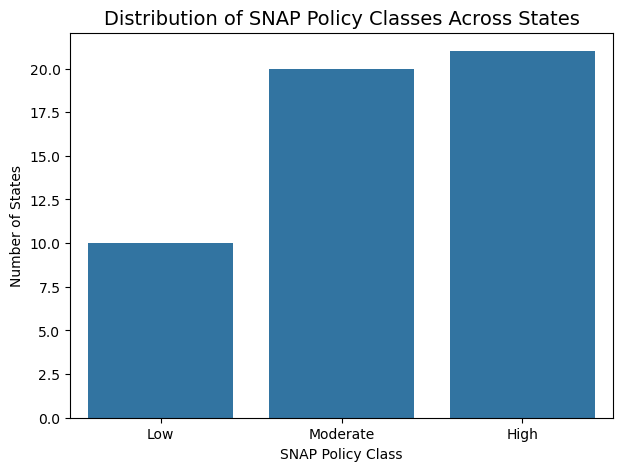

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(
    data=final_master,
    x="snap_policy_class",
    order=["Low", "Moderate", "High"]
)
plt.title("Distribution of SNAP Policy Classes Across States", fontsize=14)
plt.xlabel("SNAP Policy Class")
plt.ylabel("Number of States")
plt.show()


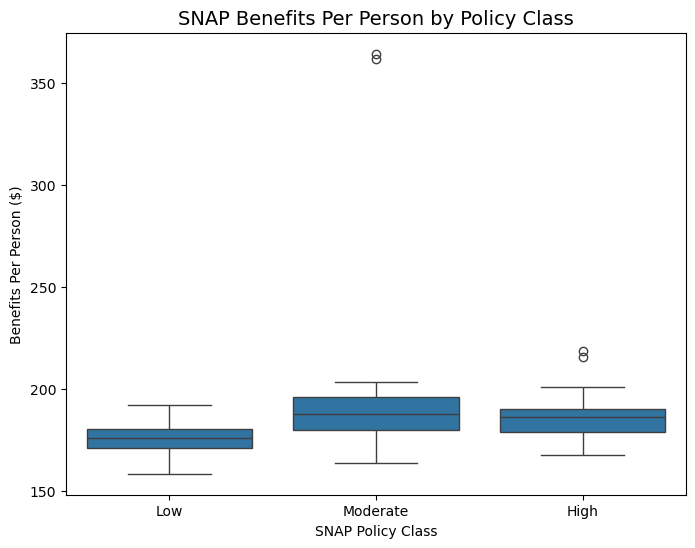

In [34]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=final_master,
    x="snap_policy_class",
    y="benefits_per_person",
    order=["Low", "Moderate", "High"]
)
plt.title("SNAP Benefits Per Person by Policy Class", fontsize=14)
plt.xlabel("SNAP Policy Class")
plt.ylabel("Benefits Per Person ($)")
plt.show()


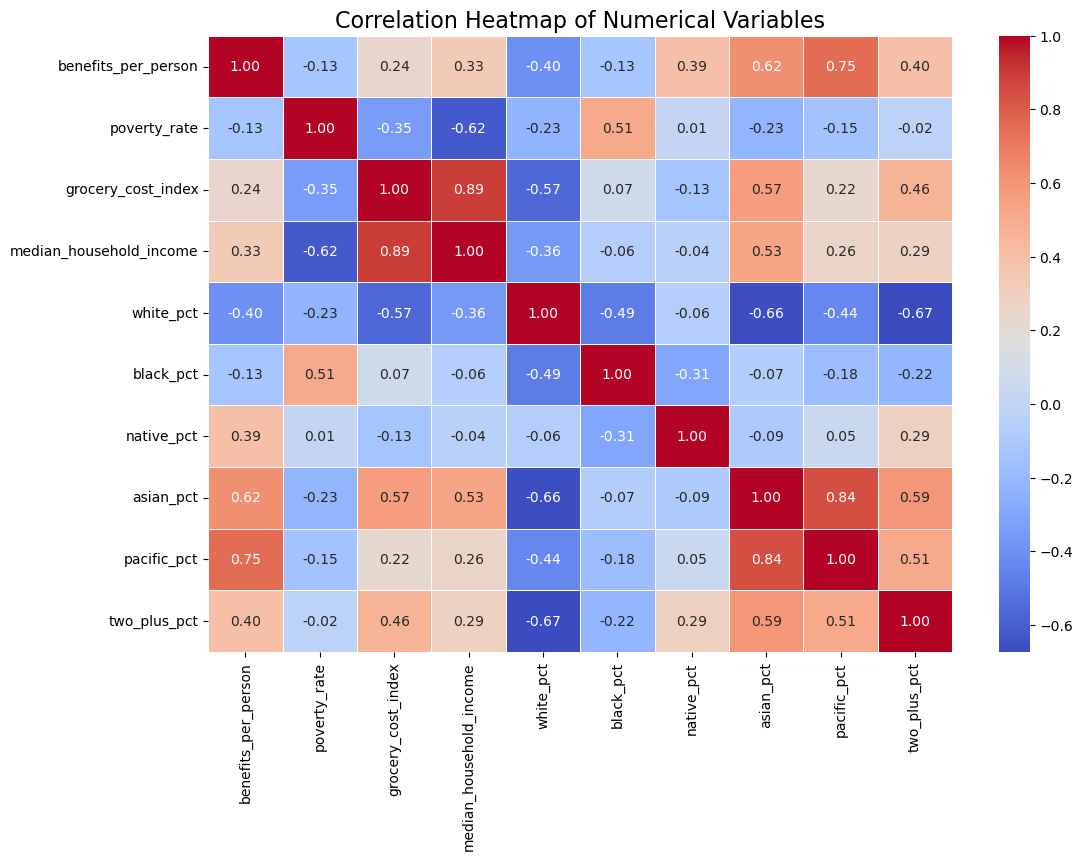

In [35]:
num_cols = [
    "benefits_per_person",
    "poverty_rate",
    "grocery_cost_index",
    "median_household_income",
    "white_pct",
    "black_pct",
    "native_pct",
    "asian_pct",
    "pacific_pct",
    "two_plus_pct"
]

corr = final_master[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Variables", fontsize=16)
plt.show()


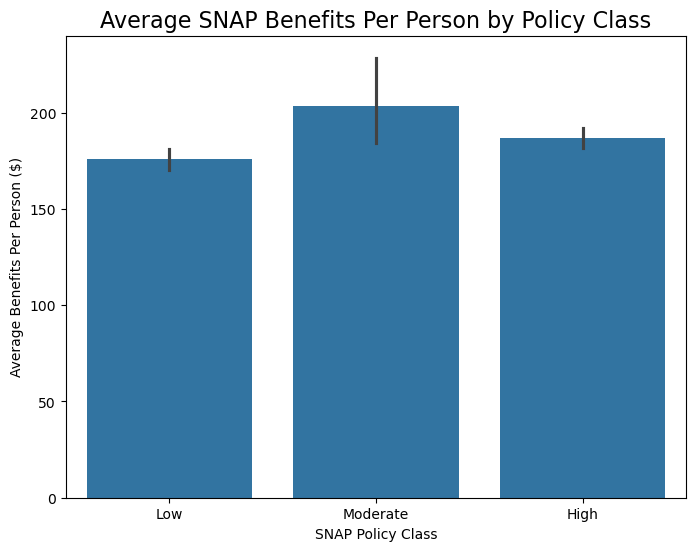

In [36]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=final_master,
    x="snap_policy_class",
    y="benefits_per_person",
    order=["Low", "Moderate", "High"]
)
plt.title("Average SNAP Benefits Per Person by Policy Class", fontsize=16)
plt.xlabel("SNAP Policy Class")
plt.ylabel("Average Benefits Per Person ($)")
plt.show()


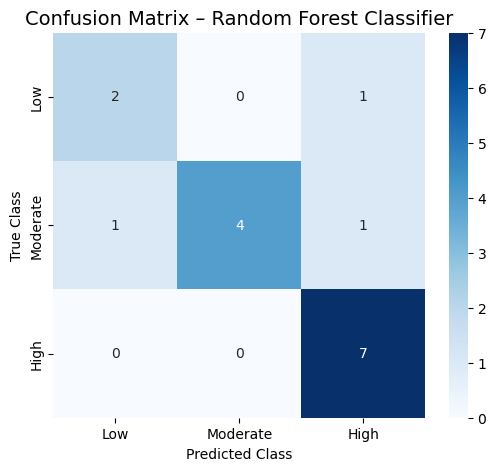

In [38]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Predict on test set
y_pred_rf = rf_clf.predict(X_test)

# Define class order explicitly
class_labels = ["Low", "Moderate", "High"]

cm = confusion_matrix(y_test, y_pred_rf, labels=class_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Confusion Matrix – Random Forest Classifier", fontsize=14)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()


/var/folders/56/z80x17wn70lfrg6fj3lvncdr0000gn/T/ipykernel_10572/2730646875.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


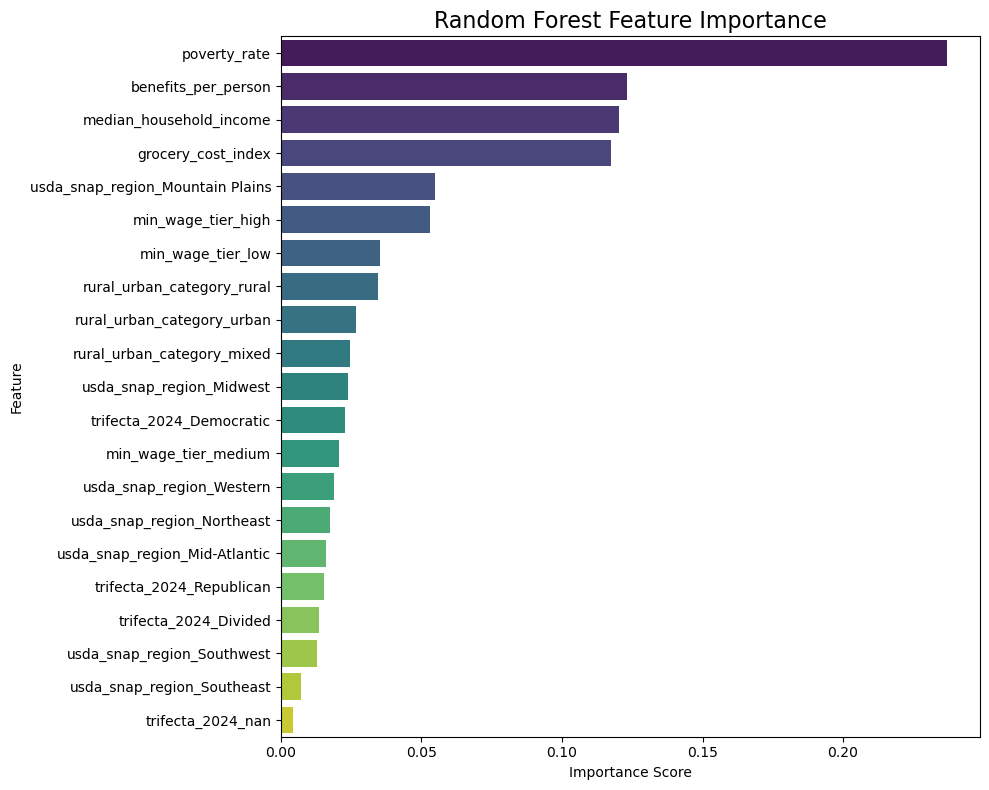

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract trained RF model from pipeline
rf_model = rf_clf.named_steps["clf"]

# Extract OHE-expanded categorical variables
ohe = preprocessor.named_transformers_["cat"]
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)

# Combine numeric + OHE categorical names
feature_names = numeric_cols + list(ohe_feature_names)

# Feature importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(
    y=np.array(feature_names)[indices],
    x=importances[indices],
    palette="viridis"
)
plt.title("Random Forest Feature Importance", fontsize=16)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
